# Mini-edlang

This week, your task is to implement an inference server for LLMs. Let's call this server **__mini-edlang__**.

Nowadays, popular inference servers (SGLang, vLLM, etc.) provide the user with a variety of features, allowing for maximum acceleration of LLM inference in a production environment. You don't need to create a production‑ready server, just implement the basic features.

The purpose of the inference server is to process the incoming flow of requests to the LLM. Requests come at random times, so it is necessary to implement **Continuous batching**. It involves more than just dividing each request into prefill and decode stages, but also keeping the current state of the request queue, making decisions about switching from prefill to decode and vice versa, collecting metrics, and providing a user‑friendly asynchronous server interface.

### Project Structure

In our implementation we are gonna divide our code in the following folders:

- __Entrypoints__:
        Here we have 2 files: __engine.py__ and __config.py__. In __engine.py__ you can find class InferenceEngine - backbone of our LLM engine implementation based upon transformers. Within config.py you will find basic configuration. Your task here will be to implement all missing methods of InferenceEngine and check if they work correctly

- __Managers__:
        This folder contains **scheduler_manager.py** and **metric_manager.py**. **scheduler_manager.py** is responsible for schedule our requests, so we can say it is the main part of our server. In **metric_manager.py** you will find drafts for MetricManager class, which you need to complete to collect metrics to profile our inference

- __Server__:
        Here you will find implementation for asynchronious server. You don't need to rewrite it (unless you have idea how to make it more efficient :))

### Grades

Your homework will be divided into four parts. The points are distributed among the parts as follows:

* Engine - 2 points + 1 bonus
* Scheduler - 2 points
* Metrics - 2 points + 1 bonus
* Scheduler policy and benchmarking - 4 points

### Environment

For your convenience, this directory contains `requirements.txt`. To easily install the dependencies with uv, you can run

```uv pip install -r requirements.txt```

Also, we recommend working inside a virtual environment, which you can also create with uv:

```
uv venv
source .venv/bin/activate 
```

Let's start!

## Part 1. Engine (2 points + 1 bonus)

In this task you need to complete all unfinished methods of InferenceEngine from __inference_server/entrypoints/engine.py__. 

Below are the assertion statements for each method; to get the full grade, you should pass all of them. Remember that passing asserts is a necessary but not a sufficient condition! Your points will be awarded based on your code implementation.

Since we manually divide our generation into prefill and decode stages, we can't use model.generate method and pass Sampling Params into it. The only way use Sampling Params is to apply them ourselves. Here, you should implement just greedy decoding.

In [1]:
import torch

from edlang.entrypoints.engine import InferenceEngine, Request
from edlang.entrypoints.config import EngineConfig, ModelConfig

In [2]:
model_config = ModelConfig(model_name="Qwen/Qwen3-4B", device="cuda:0", torch_dtype=torch.float16, max_prompt_length=512)
engine_config = EngineConfig(model_config=model_config)

engine = InferenceEngine(engine_config)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [3]:
prompt_list = [
    "Why do we need inference servers for LLMs?\n",
    "How does Continuous Batching improve LLM inference throughput?\n",
    "What is Paged Attention in the context of LLMs?\n",
    "How can we reduce the latency of LLM inference for real-time applications?\n",
    "What are the main challenges of serving large LLMs in production?\n",
]

MAX_NEW_TOKENS = 59

In [4]:
request_list = [
    Request(request_id=i, prompt=prompt, max_new_tokens=MAX_NEW_TOKENS) for i, prompt in enumerate(prompt_list)
]
token_list = [
    engine.tokenizer.encode(prompt) for prompt in prompt_list
]
batch_prefill_result = engine.prefill(request_list)

In [5]:
# check prefill - 1 point

# Batch‑level checks
assert len(batch_prefill_result.request_ids) == len(request_list)
assert len(batch_prefill_result.new_tokens) == len(request_list)
assert len(batch_prefill_result.finished) == len(request_list)
assert set(batch_prefill_result.request_ids) == {r.request_id for r in request_list}

for request, tokens in zip(request_list, token_list):
    idx = batch_prefill_result.request_ids.index(request.request_id)
    new_tokens = batch_prefill_result.new_tokens[idx]
    finished_flag = batch_prefill_result.finished[idx]

    # check if attention mask is calculated correctly
    assert len(tokens) == int(request.attention_mask.sum())

    # check if KV cache stores correctly
    num_layers = engine.model.config.num_hidden_layers
    assert num_layers == len(request.past_key_values.key_cache)

    num_kv_heads = engine.model.config.num_key_value_heads
    head_dim = engine.model.config.head_dim
    kv_shape = request.past_key_values.key_cache[0].shape
    assert kv_shape[0] == 1 and kv_shape[1] == num_kv_heads and kv_shape[3] == head_dim

In [6]:
# check decode and text generation - 2 point

answer_to_prompts = []

for request in request_list:
    for _ in range(request.max_new_tokens):
        batch_result = engine.decode([request])
        assert batch_result.request_ids == [request.request_id]
        assert len(batch_result.new_tokens) == 1
        assert len(batch_result.finished) == 1

        if request.is_finished:
            assert batch_result.finished[0] is True
            assert batch_result.finished[0] == request.is_finished

    assert request.is_finished

    # check if request is truly finished
    number_of_tokens = list(request.generated_tokens)
    for _ in range(request.max_new_tokens):
        engine.decode([request])

    assert number_of_tokens == request.generated_tokens

    print(f"{'='*20} Request #{request.request_id} {'='*20}")
    print(f"Prompt: {request.prompt!r}\n")
    print("Generated:")
    answer_to_prompts.append(engine.get_generated_text(request))
    print(answer_to_prompts[-1])
    print("="*54 + '\n')


==================== Request #0 ====================
Prompt: 'Why do we need inference servers for LLMs?\n'

Generated:
Why do we need inference servers for LLMs?
Inference servers are essential for large language models (LLMs) because they provide the computational resources and infrastructure needed to handle the high demands of running these complex models efficiently. Here are the key reasons why inference servers are necessary:

1. **Scalability**: LLMs require significant computational power

==================== Request #1 ====================
Prompt: 'How does Continuous Batching improve LLM inference throughput?\n'

Generated:
How does Continuous Batching improve LLM inference throughput?
Continuous Batching is a technique used in large language model (LLM) inference to improve throughput by efficiently utilizing the available computational resources. Here's how it works and how it improves throughput:

1. **Batching**: In traditional inference, each request is processed indiv

In [7]:
# почему-то не было теста когда несколько элементов за раз - так что вот

request_list = [
    Request(request_id=i, prompt=prompt, max_new_tokens=MAX_NEW_TOKENS) for i, prompt in enumerate(prompt_list)
]
token_list = [
    engine.tokenizer.encode(prompt) for prompt in prompt_list
]
batch_prefill_result = engine.prefill(request_list)

for request, tokens in zip(request_list, token_list):
    idx = batch_prefill_result.request_ids.index(request.request_id)
    new_tokens = batch_prefill_result.new_tokens[idx]
    finished_flag = batch_prefill_result.finished[idx]

    # check if attention mask is calculated correctly
    assert len(tokens) == int(request.attention_mask.sum())

    # check if KV cache stores correctly
    num_layers = engine.model.config.num_hidden_layers
    assert num_layers == len(request.past_key_values.key_cache)

    num_kv_heads = engine.model.config.num_key_value_heads
    head_dim = engine.model.config.head_dim
    kv_shape = request.past_key_values.key_cache[0].shape
    assert kv_shape[0] == 1 and kv_shape[1] == num_kv_heads and kv_shape[3] == head_dim


answer_to_prompts = []

for _ in range(100):
    batch_result = engine.decode(request_list)

In [8]:
for request in request_list:
    assert request.is_finished

    # check if request is truly finished
    number_of_tokens = list(request.generated_tokens)
    for _ in range(request.max_new_tokens):
        engine.decode([request])

    assert number_of_tokens == request.generated_tokens

    print(f"{'='*20} Request #{request.request_id} {'='*20}")
    print(f"Prompt: {request.prompt!r}\n")
    print("Generated:")
    answer_to_prompts.append(engine.get_generated_text(request))
    print(answer_to_prompts[-1])
    print("="*54 + '\n')


==================== Request #0 ====================
Prompt: 'Why do we need inference servers for LLMs?\n'

Generated:
Why do we need inference servers for LLMs?
Inference servers are essential for large language models (LLMs) because they provide the computational resources and infrastructure needed to handle the high demands of running these complex models efficiently. Here are the key reasons why inference servers are necessary:

1. **Scalability**: LLMs require significant computational power

==================== Request #1 ====================
Prompt: 'How does Continuous Batching improve LLM inference throughput?\n'

Generated:
How does Continuous Batching improve LLM inference throughput?
Continuous Batching is a technique used in large language model (LLM) inference to improve throughput by efficiently utilizing the available computational resources. Here's how it works and how it improves throughput:

1. **Batching**: In traditional inference, each request is processed indiv

## Bonus part - sampling parameters (1 Point)

As you saw before, our engine cannot use sampling parameters. Your bonus task is to complete the method **engine._sample** to correctly work with the following sampling params:

In [ ]:
sampling_params_list = [    
    "temperature",
    "top_k",
    "top_p",
    "do_sample",
    "eos_token_id",
    "ignore_eos_token",
]

Below are some tests that you should pass:

In [ ]:
def make_request(sampling_params):
    return Request(
        request_id=0,
        prompt="",
        max_new_tokens=1,
        sampling_params=sampling_params,
    )

logits = torch.tensor([0.1, 2.0, 0.3], device=engine.model_config.device)

In [ ]:
# We have to get the same argmax
token = engine._sample(logits, make_request(None))
assert token == 1, f"Expected greedy argmax token 1, got {token}"

In [ ]:
# Check top_k
token = engine._sample(
    logits,
    make_request({"top_k": 1, "do_sample": True}),
)
assert token == 1, f"Expected token 1 with top_k=1, got {token}"

In [ ]:
# Check top_p
logits = torch.tensor([10.0, 0.0, 0.0], device=engine.model_config.device)
token = engine._sample(
    logits,
    make_request({"top_p": 0.9, "do_sample": True}),
)
assert token == 0, f"Expected token 0 with top_p=0.9, got {token}"

In [ ]:
# check eos_token_id and ignore tokens
logits = torch.tensor([5.0, 1.0, 0.0], device=engine.model_config.device)

token = engine._sample(
    logits,
    make_request({"do_sample": True, "top_k": 1, "eos_token_id": 0}),
)
assert token == 0, f"Expected eos token 0 to be sampled, got {token}"

token = engine._sample(
    logits,
    make_request({"do_sample": True, "top_k": 1, "eos_token_id": 0, "ignore_eos_token": True}),
)
assert token == 1, f"Expected token 1 when ignore_eos_token=True, got {token}"

## Part 2.1. Scheduler (2 Points)

Now you need to implement EDLangScheduler — the scheduler that will handle our request flow. You can find the interface of this class in **inference_server/managers/scheduler_manager.py**. Again, your task is to complete all methods. If you want, you can create additional private methods for scheduler, but describe their purpose here in this notebook as part of your report

In [9]:
from edlang.managers.scheduler_manager import EDLangScheduler

In [10]:
scheduler = EDLangScheduler(engine=engine)

In [11]:
# check request registration
for i, prompt in enumerate(prompt_list):
    scheduler.add_request(prompt, max_new_tokens=MAX_NEW_TOKENS)
    assert len(scheduler.waiting_queue) == i + 1, f"Len of your request queue is {len(scheduler.waiting_queue)} for {i} requests"
    assert len(scheduler.active_requests) == 0

In [12]:
# .clear should remove all requests and reset all counters and queues
scheduler.clear()

In [13]:
scheduler.active_requests

[]

In [14]:
# check prefill step with current prefill policy
scheduler.add_request("Hello, world!", max_new_tokens=MAX_NEW_TOKENS)
scheduler._prefill_step()

for i, prompt in enumerate(prompt_list):
    scheduler.add_request(prompt, max_new_tokens=MAX_NEW_TOKENS)
    scheduler._prefill_step()
    assert len(scheduler.waiting_queue) == i + 1, f"Prefill schould transform request from waiting to active if there are no active requests, but you got {len(scheduler.waiting_queue)} waiting requests"
    assert len(scheduler.active_requests) == 1


In [15]:
scheduler.clear()

In [16]:
# check decode step
error_list = []

for i, prompt in enumerate(prompt_list):
    scheduler.add_request(prompt, max_new_tokens=MAX_NEW_TOKENS)
    request = scheduler.waiting_queue[-1]
    scheduler._prefill_step()

    for _ in range(request.max_new_tokens):
        scheduler._decode_step()
    
    finished_request = scheduler.get_finished_requests()[0]

    assert finished_request.is_finished
    assert finished_request == request

    print(f"{'='*20} Request #{finished_request.request_id} {'='*20}")
    print(f"Prompt: {finished_request.prompt!r}\n")
    print("Generated:")
    scheduler_answer = scheduler.engine.get_generated_text(finished_request)

    if scheduler_answer != answer_to_prompts[i]:
        error_list.append(f"Expected: {answer_to_prompts[i]}, \n\nGot: {scheduler_answer}")
    print(scheduler_answer)
    print("="*54 + '\n')

==================== Request #11 ====================
Prompt: 'Why do we need inference servers for LLMs?\n'

Generated:
Why do we need inference servers for LLMs?
Inference servers are essential for large language models (LLMs) because they provide the computational resources and infrastructure needed to handle the high demands of running these complex models efficiently. Here are the key reasons why inference servers are necessary:

1. **Scalability**: LLMs require significant computational power

==================== Request #12 ====================
Prompt: 'How does Continuous Batching improve LLM inference throughput?\n'

Generated:
How does Continuous Batching improve LLM inference throughput?
Continuous Batching is a technique used in large language model (LLM) inference to improve throughput by efficiently utilizing the available computational resources. Here's how it works and how it improves throughput:

1. **Batching**: In traditional inference, each request is processed ind

Below you can see how many generations differs from different approaches

In [17]:
assert len(error_list) < len(prompt_list) / 4, "You have too many errors in your code"

for error in error_list:
    print(error)

If you passed all assert statements above, then (probably) your code is working and we can benchmark it like a real production inference server! But firstly, we need to implement the metrics

## Part 2.2. Metrics (2 point + 1 Bonus)

To properly evaluate and benchmark our inference server, we need to understand what metrics to measure. When talking about LLM inference, there are plenty of metrics we can collect. Your task is to implement the calculation of the following basic metrics:

### Core Metrics

* **Generation Throughput** (Gen throughput) - measured in tokens per second. This metric quantifies the overall generation speed of the inference server. It is calculated as the total number of tokens generated across all requests in one second during the decode step. Higher throughput indicates better server efficiency and capacity to handle multiple concurrent requests.

* **Time To First Token (TTFT)** - measures the latency between when a request is submitted to the inference server and when the first generated token is returned to the client. This is a critical metric for user experience, especially in interactive applications like chatbots, as it determines the perceived responsiveness of the system.

* **Time Per Output Token (TPOT)** or **Inter-token Latency** - the average time between generating consecutive tokens during the decode phase. It is calculated as the decode time divided by the number of generated tokens. This metric helps understand the steady-state generation speed.

* **Request Throughput** - measured in requests per second (RPS). This indicates how many complete requests the server can process per unit of time, which is important for understanding the server's capacity under load.

The main code for the metrics lies in **inference_server/managers/metric_manager.py**. You have some requirements for this class's interface, but the inner implementaion of the methods is up to you

In [18]:
# To enable metrics we need to pass enable_metrics=True to EDLangScheduler constructor
from edlang.managers.scheduler_manager import SchedulerConfig

scheduler_config = SchedulerConfig(enable_metrics=True)

scheduler = EDLangScheduler(engine=engine, config=scheduler_config)

# check metrics
for i, prompt in enumerate(prompt_list):
    scheduler.add_request(prompt, max_new_tokens=MAX_NEW_TOKENS)
    assert scheduler.metrics_manager.waiting_queue_num == 1

    # first step is prefill step
    scheduler.step()

    for i in range(MAX_NEW_TOKENS):
        scheduler.step()
        assert scheduler.metrics_manager.waiting_queue_num == 0
        assert scheduler.metrics_manager.active_requests_num == 1
        assert scheduler.metrics_manager.throughput_tokens_per_second > 0
    
    finished_request = scheduler.get_finished_requests()[0]

In [19]:
scheduler.clear()
MAX_NEW_TOKENS = 256

# let's collect requests
for i, prompt in enumerate(prompt_list):
    scheduler.add_request(prompt, max_new_tokens=MAX_NEW_TOKENS)
    # assert scheduler.metrics_manager.waiting_queue_num == 1

    scheduler.step()

    assert scheduler.metrics_manager.active_requests_num > 0
    assert scheduler.metrics_manager.throughput_tokens_per_second > 0

print(f"all requests have been added")

for _ in range(MAX_NEW_TOKENS - len(prompt_list) - 1):
    scheduler.step()
    assert scheduler.metrics_manager.active_requests_num > 0
    assert scheduler.metrics_manager.throughput_tokens_per_second > 0

for i in range(len(prompt_list)):
    scheduler.step()
    assert scheduler.metrics_manager.throughput_tokens_per_second > 0

    # get_finished_requests should be the only way to remove a finished request from active requests
    scheduler.get_finished_requests()


all requests have been added


### BONUS: Additional Important Metrics in LLM Inference (1 point)

While you only need to implement the metrics above, here are other commonly used metrics in production LLM inference systems.Adding each one will grant you extra 0.25 points:

* **End-to-End Latency (Total Time)** - the total time from request submission to completion (when the last token is generated or the request finishes). This is the sum of TTFT and the time to generate all remaining tokens.

* **GPU Utilization** - the percentage of time the GPU is actively performing computations. High utilization indicates efficient use of hardware resources, while low utilization may suggest bottlenecks elsewhere (e.g., memory bandwidth, CPU preprocessing).

* **Memory Usage** - tracks GPU memory consumption, including model weights, KV cache, and intermediate activations. This is crucial for understanding resource constraints and optimizing batch sizes.

* **Queue Wait Time** - the time a request spends waiting in the queue before being processed. This metric is important for understanding server load and scheduling efficiency, especially under high traffic conditions.

In [20]:
# Show how your additional metrics work here

## Part 3. Scheduler Policy (4 points)

Now we have a functioning engine, scheduler, and metrics system, but our inference framework is still far from optimal. The main limitation lies in our scheduler, specifically in the `_decide_prefill_batch_size` function, which currently makes very inefficient decisions regarding prefill and decode handling.

Your task is to iteratively experiment and develop better strategies to optimize this function. Design and implement at least **THREE** different policies for deciding the prefill batch size, and benchmark their performance.

For each policy you try, analyze the impact on throughput, latency, and overall efficiency. Compare the results and determine which approach works best in practice. This is an open-ended, exploratory exercise: be creative and systematic in your experimentation, and justify your conclusions based on your findings.

Below you can see an example of a benchmarking function. It takes RPS, number of requests and mode for testing
* hard_prefill - huge prompt and small max_new_tokens
* hard_decode - small prompt and huge max_new_tokens
* medium - same size for prompt and max_new_tokens

To start your server, you can open an additional terminal and run

```
python -m edlang.server.launch
```

Note: see what additional arguments you can pass with parser.

Example of a benchmark call:

In [1]:
results = {}

In [12]:
from edlang.test_benchmark import benchmark
import json

results['baseline_hard_decode'] = benchmark(mode="hard_decode", rps=1/20, num_requests=10)

[Benchmark] mode=hard_decode, target_rps=0.05, num_requests=10
[Benchmark] prompt_len=50 chars, max_new_tokens=2000
[Benchmark] Warmup: 2 requests...


[Benchmark] Warmup done.
[Benchmark] Sending 10 requests at 0.05 RPS (delay=20.000s between starts)...
  -> Sent 1/10 (rate: 0.0 req/s)
  -> Sent 2/10 (rate: 0.0 req/s)
  -> Sent 3/10 (rate: 0.0 req/s)
  -> Sent 4/10 (rate: 0.0 req/s)
  -> Sent 5/10 (rate: 0.0 req/s)
  -> Sent 6/10 (rate: 0.0 req/s)
  -> Sent 7/10 (rate: 0.0 req/s)
  -> Sent 8/10 (rate: 0.0 req/s)
  -> Sent 9/10 (rate: 0.0 req/s)
  -> Sent 10/10 (rate: 0.0 req/s)
[Benchmark] All requests sent in 200.16s. Waiting for responses...
[Benchmark] Done. Success: 10/10
  latency: avg=349714ms, p95=547049ms
  throughput: 0.01 req/s


In [3]:
from edlang.test_benchmark import benchmark
import json

results['baseline_hard_prefill'] = benchmark(mode="hard_prefill", rps=2.0, num_requests=10)

[Benchmark] mode=hard_prefill, target_rps=2.0, num_requests=10
[Benchmark] prompt_len=2000 chars, max_new_tokens=20
[Benchmark] Warmup: 2 requests...


[Benchmark] Warmup done.
[Benchmark] Sending 10 requests at 2.0 RPS (delay=0.500s between starts)...
  -> Sent 1/10 (rate: 2.0 req/s)
  -> Sent 2/10 (rate: 2.0 req/s)
  -> Sent 3/10 (rate: 2.0 req/s)
  -> Sent 4/10 (rate: 2.0 req/s)
  -> Sent 5/10 (rate: 2.0 req/s)
  -> Sent 6/10 (rate: 2.0 req/s)
  -> Sent 7/10 (rate: 2.0 req/s)
  -> Sent 8/10 (rate: 2.0 req/s)
  -> Sent 9/10 (rate: 2.0 req/s)
  -> Sent 10/10 (rate: 2.0 req/s)
[Benchmark] All requests sent in 5.02s. Waiting for responses...
[Benchmark] Done. Success: 10/10
  latency: avg=2158ms, p95=3507ms
  throughput: 1.17 req/s


In [4]:
from edlang.test_benchmark import benchmark
import json

results['baseline_medium'] = benchmark(mode="medium", rps=2.0, num_requests=10)

[Benchmark] mode=medium, target_rps=2.0, num_requests=10
[Benchmark] prompt_len=200 chars, max_new_tokens=200
[Benchmark] Warmup: 2 requests...


[Benchmark] Warmup done.
[Benchmark] Sending 10 requests at 2.0 RPS (delay=0.500s between starts)...
  -> Sent 1/10 (rate: 2.0 req/s)
  -> Sent 2/10 (rate: 2.0 req/s)
  -> Sent 3/10 (rate: 2.0 req/s)
  -> Sent 4/10 (rate: 2.0 req/s)
  -> Sent 5/10 (rate: 2.0 req/s)
  -> Sent 6/10 (rate: 2.0 req/s)
  -> Sent 7/10 (rate: 2.0 req/s)
  -> Sent 8/10 (rate: 2.0 req/s)
  -> Sent 9/10 (rate: 2.0 req/s)
  -> Sent 10/10 (rate: 2.0 req/s)
[Benchmark] All requests sent in 5.02s. Waiting for responses...
[Benchmark] Done. Success: 10/10
  latency: avg=41843ms, p95=75638ms
  throughput: 0.12 req/s


Now, you can change the `_decide_prefill_batch_size` function, collect the results, and write a report summarizing what you did and how it helped to imporve performance

* Analysis and visualization: You can add any functions to analyze results: build plots (matplotlib, seaborn), compute statistics, compare policies. Use the cells below for your report.

* Changing the benchmark: If you have a strong reason to modify the benchmark code (test_benchmark.py), you may do so, but you must justify the changes in your report (why, what exactly you changed, and how it affects the results).


изначальный вариант всегда обрабатывает запросы последовательно тк он делает первым префил и потом есть кто-то для декода и поэтому он делает его

попробуем наоборот - пока есть кому делать префил будем делать его, это может быть лучше тк так мы реально будет использовать батчи

In [9]:
from edlang.test_benchmark import benchmark
import json

results['prefill_first_hard_decode'] = benchmark(mode="hard_decode", rps=1/20, num_requests=10)

[Benchmark] mode=hard_decode, target_rps=0.05, num_requests=10
[Benchmark] prompt_len=50 chars, max_new_tokens=2000
[Benchmark] Warmup: 2 requests...


[Benchmark] Warmup done.
[Benchmark] Sending 10 requests at 0.05 RPS (delay=20.000s between starts)...
  -> Sent 1/10 (rate: 0.0 req/s)
  -> Sent 2/10 (rate: 0.0 req/s)
  -> Sent 3/10 (rate: 0.0 req/s)
  -> Sent 4/10 (rate: 0.0 req/s)
  -> Sent 5/10 (rate: 0.0 req/s)
  -> Sent 6/10 (rate: 0.0 req/s)
  -> Sent 7/10 (rate: 0.0 req/s)
  -> Sent 8/10 (rate: 0.0 req/s)
  -> Sent 9/10 (rate: 0.0 req/s)
  -> Sent 10/10 (rate: 0.0 req/s)
[Benchmark] All requests sent in 200.11s. Waiting for responses...
[Benchmark] Done. Success: 10/10
  latency: avg=99579ms, p95=121837ms
  throughput: 0.03 req/s


In [10]:
from edlang.test_benchmark import benchmark
import json

results['prefill_first_hard_prefill'] = benchmark(mode="hard_prefill", rps=2.0, num_requests=10)
results['prefill_first_medium'] = benchmark(mode="medium", rps=2.0, num_requests=10)

[Benchmark] mode=hard_prefill, target_rps=2.0, num_requests=10
[Benchmark] prompt_len=2000 chars, max_new_tokens=20
[Benchmark] Warmup: 2 requests...
[Benchmark] Warmup done.
[Benchmark] Sending 10 requests at 2.0 RPS (delay=0.500s between starts)...
  -> Sent 1/10 (rate: 2.0 req/s)
  -> Sent 2/10 (rate: 2.0 req/s)
  -> Sent 3/10 (rate: 2.0 req/s)
  -> Sent 4/10 (rate: 2.0 req/s)
  -> Sent 5/10 (rate: 2.0 req/s)
  -> Sent 6/10 (rate: 2.0 req/s)
  -> Sent 7/10 (rate: 2.0 req/s)
  -> Sent 8/10 (rate: 2.0 req/s)
  -> Sent 9/10 (rate: 2.0 req/s)
  -> Sent 10/10 (rate: 2.0 req/s)
[Benchmark] All requests sent in 5.03s. Waiting for responses...
[Benchmark] Done. Success: 10/10
  latency: avg=1082ms, p95=1139ms
  throughput: 1.67 req/s
[Benchmark] mode=medium, target_rps=2.0, num_requests=10
[Benchmark] prompt_len=200 chars, max_new_tokens=200
[Benchmark] Warmup: 2 requests...
[Benchmark] Warmup done.
[Benchmark] Sending 10 requests at 2.0 RPS (delay=0.500s between starts)...
  -> Sent 1/10 (

следующий вариант попробовать сбалансировать то сколько делаем префил и сколько декод - для этого префил делается каждый 40й шаг либо когда нет активных запросов

In [13]:
from edlang.test_benchmark import benchmark
import json

results['fair_time_hard_decode'] = benchmark(mode="hard_decode", rps=1/20, num_requests=10)
results['fair_time_hard_prefill'] = benchmark(mode="hard_prefill", rps=2.0, num_requests=10)
results['fair_time_medium'] = benchmark(mode="medium", rps=2.0, num_requests=10)

[Benchmark] mode=hard_decode, target_rps=0.05, num_requests=10
[Benchmark] prompt_len=50 chars, max_new_tokens=2000
[Benchmark] Warmup: 2 requests...
[Benchmark] Warmup done.
[Benchmark] Sending 10 requests at 0.05 RPS (delay=20.000s between starts)...
  -> Sent 1/10 (rate: 0.0 req/s)
  -> Sent 2/10 (rate: 0.0 req/s)
  -> Sent 3/10 (rate: 0.0 req/s)
  -> Sent 4/10 (rate: 0.0 req/s)
  -> Sent 5/10 (rate: 0.0 req/s)
  -> Sent 6/10 (rate: 0.0 req/s)
  -> Sent 7/10 (rate: 0.0 req/s)
  -> Sent 8/10 (rate: 0.0 req/s)
  -> Sent 9/10 (rate: 0.0 req/s)
  -> Sent 10/10 (rate: 0.0 req/s)
[Benchmark] All requests sent in 200.12s. Waiting for responses...
[Benchmark] Done. Success: 10/10
  latency: avg=117070ms, p95=134604ms
  throughput: 0.03 req/s
[Benchmark] mode=hard_prefill, target_rps=2.0, num_requests=10
[Benchmark] prompt_len=2000 chars, max_new_tokens=20
[Benchmark] Warmup: 2 requests...
[Benchmark] Warmup done.
[Benchmark] Sending 10 requests at 2.0 RPS (delay=0.500s between starts)...
  

нам выгодно обрабатывать в батчах - поэтому еще один вариант - это обрабатывать активные запросы когда собирается полный батч

In [14]:
from edlang.test_benchmark import benchmark
import json

results['wait_batch_hard_decode'] = benchmark(mode="hard_decode", rps=1/20, num_requests=10)
results['wait_batch_hard_prefill'] = benchmark(mode="hard_prefill", rps=2.0, num_requests=10)
results['wait_batch_medium'] = benchmark(mode="medium", rps=2.0, num_requests=10)

[Benchmark] mode=hard_decode, target_rps=0.05, num_requests=10
[Benchmark] prompt_len=50 chars, max_new_tokens=2000
[Benchmark] Warmup: 2 requests...
[Benchmark] Warmup done.
[Benchmark] Sending 10 requests at 0.05 RPS (delay=20.000s between starts)...
  -> Sent 1/10 (rate: 0.0 req/s)
  -> Sent 2/10 (rate: 0.0 req/s)
  -> Sent 3/10 (rate: 0.0 req/s)
  -> Sent 4/10 (rate: 0.0 req/s)
  -> Sent 5/10 (rate: 0.0 req/s)
  -> Sent 6/10 (rate: 0.0 req/s)
  -> Sent 7/10 (rate: 0.0 req/s)
  -> Sent 8/10 (rate: 0.0 req/s)
  -> Sent 9/10 (rate: 0.0 req/s)
  -> Sent 10/10 (rate: 0.0 req/s)
[Benchmark] All requests sent in 200.14s. Waiting for responses...
[Benchmark] Done. Success: 10/10
  latency: avg=125777ms, p95=134406ms
  throughput: 0.03 req/s
[Benchmark] mode=hard_prefill, target_rps=2.0, num_requests=10
[Benchmark] prompt_len=2000 chars, max_new_tokens=20
[Benchmark] Warmup: 2 requests...
[Benchmark] Warmup done.
[Benchmark] Sending 10 requests at 2.0 RPS (delay=0.500s between starts)...
  

In [16]:
# import pickle
# with open('results.pkl', 'wb') as f: # just in case :)
#     pickle.dump(results, f)

In [26]:
results['baseline_hard_decode']

{'mode': 'hard_decode',
 'requests': [{'request_id': 0,
   'response': 'now way has did use prompt get can X8jgmTkufSg4SuH7K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K9K

In [45]:
import re
import pandas as pd
rows = []
for key, payload in results.items():
    modes = ['hard_decode', 'hard_prefill', 'medium']
    mode = None
    for m in modes:
        if m in key:
            mode = m
            break
    policy = key.replace(f"_{mode}", "")
    st = payload['statistics']
    lat = st['latency']
    rows.append({
        "key": key,
        "policy": policy,
        "mode": mode,
        "success": st["successful_requests"],
        "actual_rps": st["actual_rps"],
        "avg_s": lat["avg"],
        "p95_s": lat["p95"],
    })
df = pd.DataFrame(rows).sort_values(["mode", "policy"]).reset_index(drop=True)
display(df)

,key,policy,mode,success,actual_rps,avg_s,p95_s
0,baseline_hard_decode,baseline,hard_decode,10,0.013604,349.714336,547.049274
1,fair_time_hard_decode,fair_time,hard_decode,10,0.031488,117.069936,134.604470
2,prefill_first_hard_decode,prefill_first,hard_decode,10,0.032200,99.579174,121.837372
3,wait_batch_hard_decode,wait_batch,hard_decode,10,0.031454,125.776583,134.405773
4,baseline_hard_prefill,baseline,hard_prefill,10,1.172135,2.158499,3.506854
5,fair_time_hard_prefill,fair_time,hard_prefill,10,1.621391,1.205460,1.633348
6,prefill_first_hard_prefill,prefill_first,hard_prefill,10,1.673879,1.082293,1.138768
7,wait_batch_hard_prefill,wait_batch,hard_prefill,10,1.543703,1.267782,1.780661
8,baseline_medium,baseline,medium,10,0.123987,41.843064,75.638094
9,fair_time_medium,fair_time,medium,10,0.470411,15.989256,17.238750


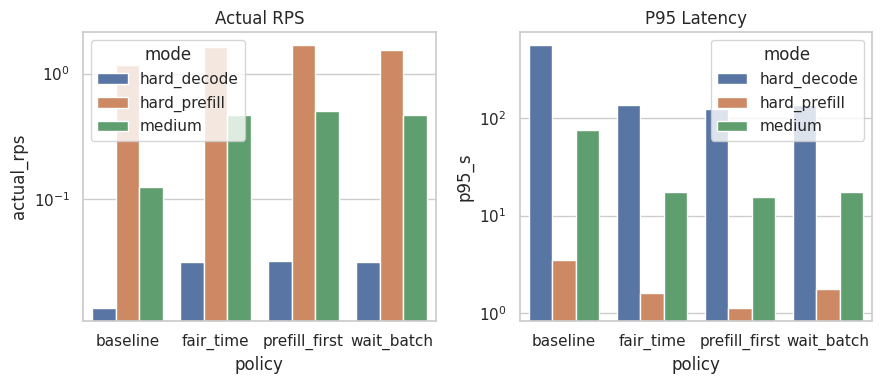

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

sns.barplot(data=df, x="policy", y="actual_rps", hue="mode", ax=axes[0])
axes[0].set_title("Actual RPS")
axes[0].tick_params(axis="x")
axes[0].set_yscale("log")

sns.barplot(data=df, x="policy", y="p95_s", hue="mode", ax=axes[1])
axes[1].set_title("P95 Latency")
axes[1].tick_params(axis="x")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

видно что больше всего проблем возникает на hard_decode задачах

базовый алгоритм работает критически плохо относительно остальных тк он вообще не использует батчи - лучше всего работает prefill_first он на всех способах выдает наилучшию скорость - в целом не зря его используют часто

также два других варианта которые я реализовывал достаточно близки к prefill_first но чуть похуже и все еще в 3 раза быстрее чем базовый

## Comments

Leave any comments about the homework here: what you liked, what was difficult, suggestions for improvement, remarks, etc

In [ ]:
# Your comments here